# Week 3 — Customer Segmentation Using K-Means Clustering

## Unsupervised Learning and Clustering Analysis

**Dataset:** Mall Customers Dataset  
**Algorithm:** K-Means Clustering  
**Programming Language:** Python  
**Libraries:** Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

In [5]:
# Week 3 - Customer Segmentation Using K-Means Clustering

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
# Upload the Mall Customers dataset

from google.colab import files

uploaded = files.upload()

print("\nUploaded file(s):")
for filename in uploaded.keys():
    print(filename)

Saving Mall_Customers.csv to Mall_Customers (1).csv

Uploaded file(s):
Mall_Customers (1).csv


In [7]:
# Load the Mall Customers dataset

df = pd.read_csv("Mall_Customers.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (200, 5)


In [8]:
# Display the first five rows

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
# Display the last five rows

df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [10]:
# Display dataset information

print("Dataset Information:")
print()

df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [11]:
# Display column names

print("Columns in the dataset:")

for column in df.columns:
    print("-", column)

Columns in the dataset:
- CustomerID
- Gender
- Age
- Annual Income (k$)
- Spending Score (1-100)


In [12]:
# Display number of rows and columns

rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 200
Number of columns: 5


In [13]:
# Descriptive statistics for numerical variables

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [14]:
# Descriptive statistics including categorical variables

df.describe(include="all")

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


In [15]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total missing values: 0


In [16]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [17]:
# Check data types

print("Data types of each column:")
print(df.dtypes)

Data types of each column:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


In [18]:
# Check data types

print("Data types of each column:")
print(df.dtypes)

Data types of each column:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


In [19]:
# Analyze gender distribution

gender_counts = df["Gender"].value_counts()

print("Gender distribution:")
print(gender_counts)

print("\nGender distribution in percentage:")
print(
    (df["Gender"].value_counts(normalize=True) * 100)
    .round(2)
)

Gender distribution:
Gender
Female    112
Male       88
Name: count, dtype: int64

Gender distribution in percentage:
Gender
Female    56.0
Male      44.0
Name: proportion, dtype: float64


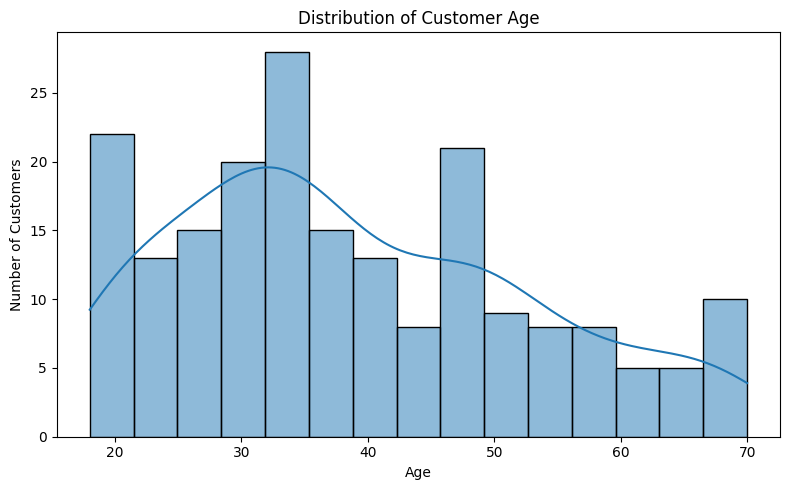

In [20]:
# Distribution of customer age

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True
)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

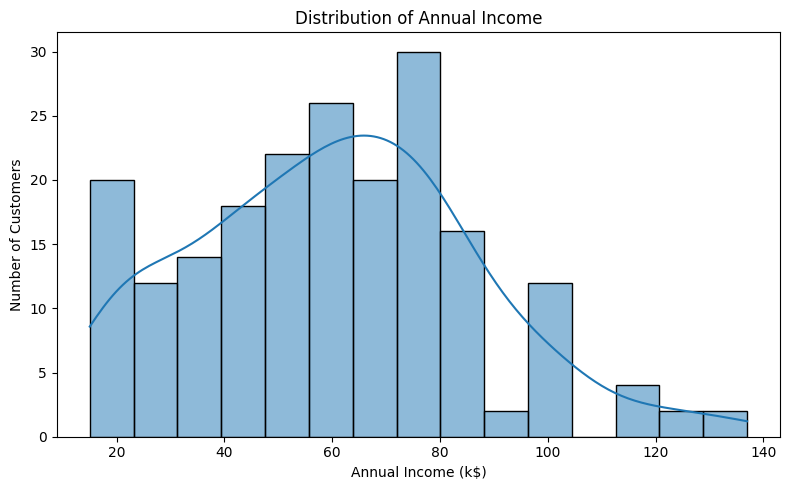

In [21]:
# Distribution of annual income

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Annual Income (k$)",
    bins=15,
    kde=True
)

plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

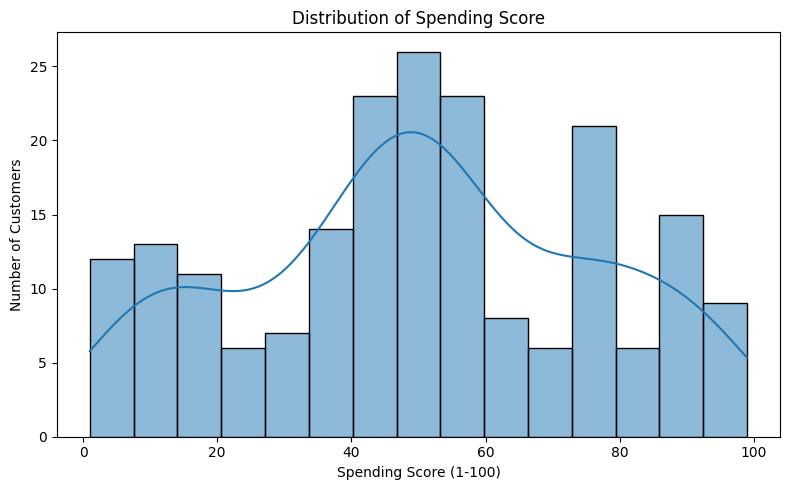

In [22]:
# Distribution of spending score

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Spending Score (1-100)",
    bins=15,
    kde=True
)

plt.title("Distribution of Spending Score")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

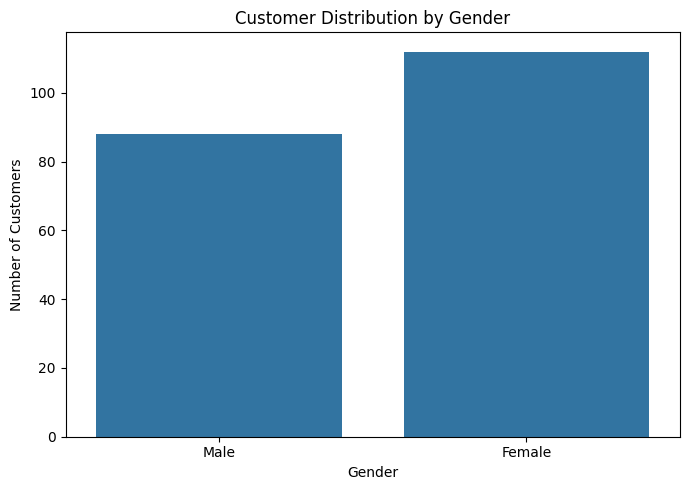

In [23]:
# Visualize customer distribution by gender

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

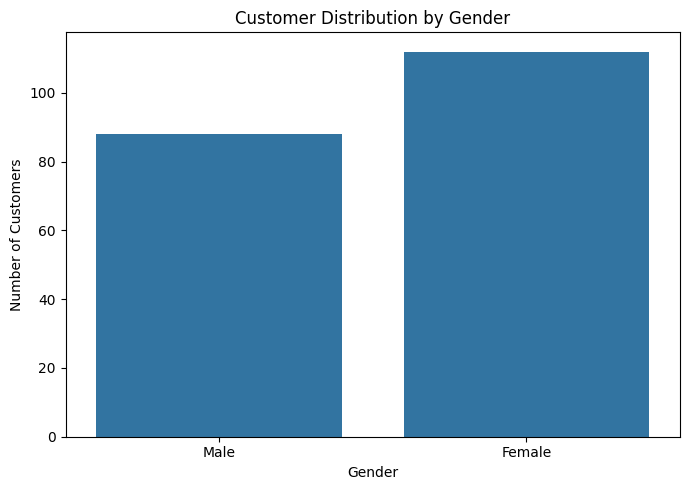

In [24]:
# Visualize customer distribution by gender

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [25]:
# Select meaningful numerical features for clustering

clustering_features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[clustering_features].copy()

print("Selected clustering features:")
for feature in clustering_features:
    print("-", feature)

print("\nFeature matrix shape:", X.shape)

X.head()

Selected clustering features:
- Age
- Annual Income (k$)
- Spending Score (1-100)

Feature matrix shape: (200, 3)


,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


## Feature Selection Rationale

Three numerical variables were selected for customer segmentation: Age, Annual Income (k$), and Spending Score (1-100).

CustomerID was excluded because it is only an identifier and does not represent a meaningful customer characteristic. Using CustomerID in a distance-based clustering algorithm could introduce artificial numerical relationships.

Gender was retained in the original dataset for descriptive and post-clustering analysis but was not directly used as a clustering feature because the primary clustering analysis focuses on the numerical customer characteristics.

Age represents customer demographics, Annual Income represents purchasing capacity, and Spending Score represents customer spending behavior. These three variables together provide complementary information for identifying meaningful customer segments.

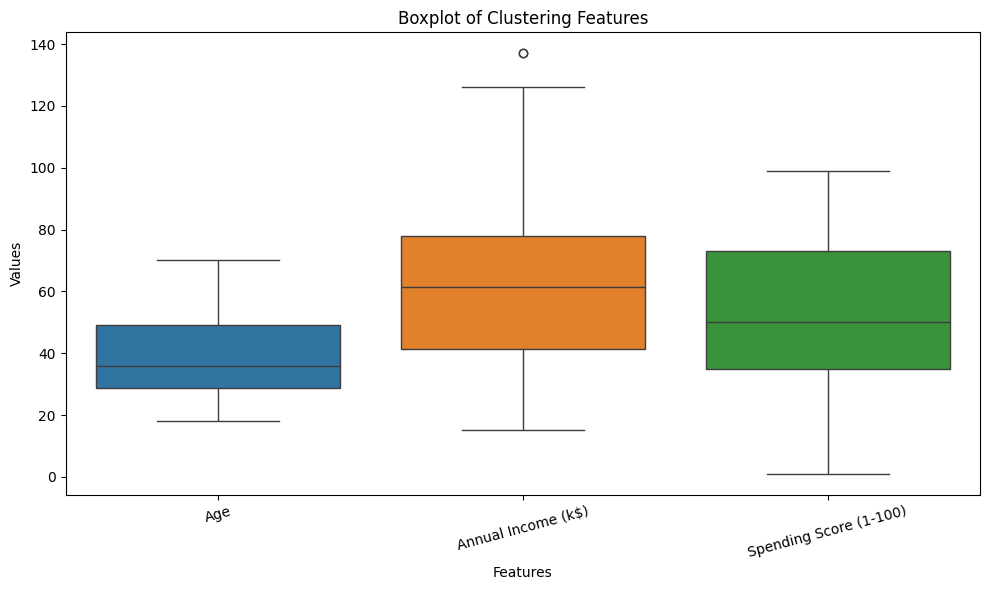

In [26]:
# Examine the distributions and potential outliers

plt.figure(figsize=(10, 6))

sns.boxplot(data=X)

plt.title("Boxplot of Clustering Features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [27]:
# Identify potential outliers using the IQR method

outlier_summary = []

for column in clustering_features:

    Q1 = X[column].quantile(0.25)
    Q3 = X[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = X[
        (X[column] < lower_bound) |
        (X[column] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": column,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Potential Outliers": len(outliers)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers
0,Age,28.75,49.0,20.25,-1.62,79.38,0
1,Annual Income (k$),41.50,78.0,36.50,-13.25,132.75,2
2,Spending Score (1-100),34.75,73.0,38.25,-22.62,130.38,0


## Outlier Handling Decision

Potential outliers were examined using the Interquartile Range (IQR) method. The identified observations were not automatically removed because extreme income or spending values can represent genuine customers and may be important for customer segmentation.

Removing such observations could eliminate potentially meaningful customer groups. Therefore, the original observations are retained, while feature scaling is applied before K-Means clustering.

This approach preserves the available customer information while ensuring that the selected variables are placed on comparable scales.

In [28]:
# Standardize the clustering features

scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=clustering_features
)

print("Standardization completed.")

X_scaled.head()

Standardization completed.


,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [29]:
# Verify the mean and standard deviation after scaling

scaling_check = pd.DataFrame({
    "Mean": X_scaled.mean(),
    "Standard Deviation": X_scaled.std()
})

scaling_check.round(4)

,Mean,Standard Deviation
Age,-0.0,1.0025
Annual Income (k$),-0.0,1.0025
Spending Score (1-100),-0.0,1.0025


## Feature Scaling Rationale

K-Means is a distance-based clustering algorithm. The selected variables have different numerical ranges, so a feature with a larger numerical scale could have a greater influence on the distance calculation.

StandardScaler was therefore applied to transform the selected features to comparable scales. This allows Age, Annual Income, and Spending Score to contribute more fairly to the clustering process.

The scaled values are used for model training, while the original values are retained for interpreting the customer segments. This separation makes the final cluster descriptions easier to understand because the reported averages remain in their original units.

In [30]:
# Calculate K-Means inertia for different numbers of clusters

inertia_values = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia_values.append(kmeans.inertia_)

elbow_results = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertia_values
})

elbow_results.round(2)

,K,Inertia
0,2,389.39
1,3,295.21
2,4,205.23
3,5,168.25
4,6,133.87
5,7,117.01
6,8,103.87
7,9,93.09
8,10,82.39


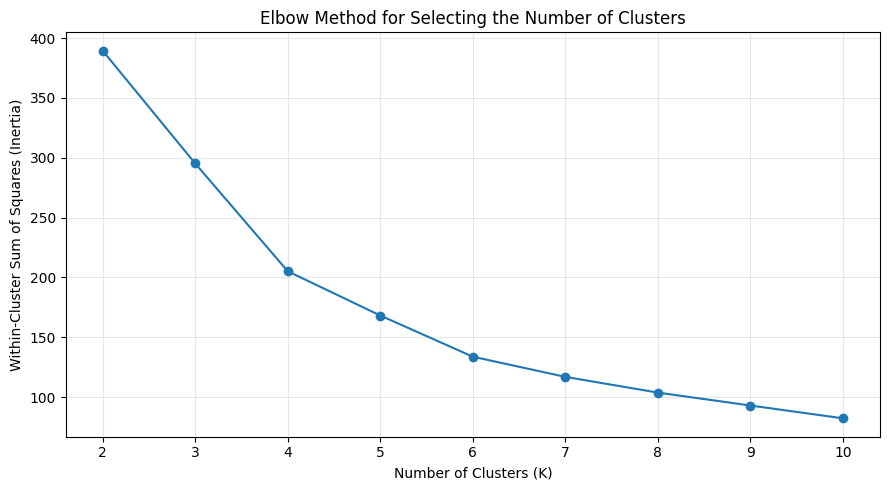

In [31]:
# Visualize the Elbow Method

plt.figure(figsize=(9, 5))

plt.plot(
    list(K_range),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for Selecting the Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# Calculate silhouette scores for different numbers of clusters

silhouette_values = []

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_values.append(score)

silhouette_results = pd.DataFrame({
    "K": list(K_range),
    "Silhouette Score": silhouette_values
})

silhouette_results.round(4)

,K,Silhouette Score
0,2,0.3355
1,3,0.3578
2,4,0.4040
3,5,0.4166
4,6,0.4284
5,7,0.4172
6,8,0.4082
7,9,0.4177
8,10,0.4066


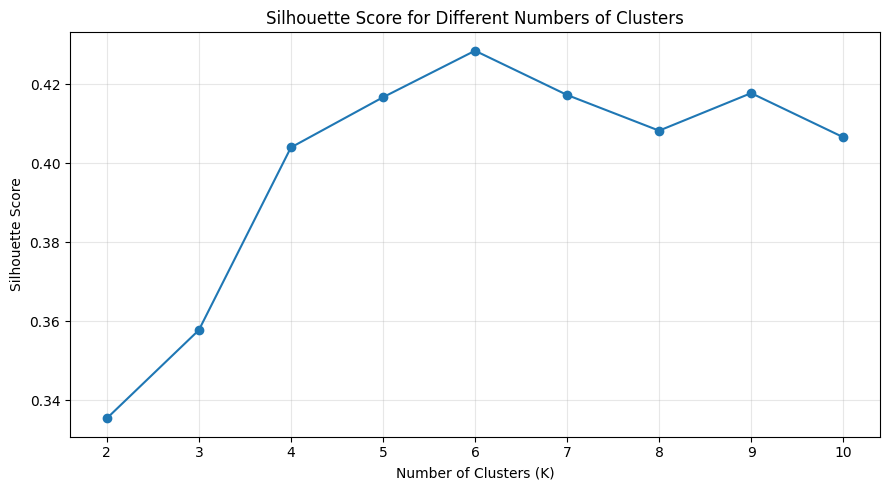

In [33]:
# Visualize silhouette scores

plt.figure(figsize=(9, 5))

plt.plot(
    list(K_range),
    silhouette_values,
    marker="o"
)

plt.title("Silhouette Score for Different Numbers of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# Identify the K value with the highest silhouette score

best_k_index = np.argmax(silhouette_values)

best_k = list(K_range)[best_k_index]

best_silhouette = silhouette_values[best_k_index]

print("Best K based on the highest silhouette score:", best_k)
print("Corresponding silhouette score:", round(best_silhouette, 4))

Best K based on the highest silhouette score: 6
Corresponding silhouette score: 0.4284


## Selection of the Number of Clusters

Multiple values of K were evaluated instead of selecting the number of clusters arbitrarily.

The Elbow Method was used to examine how the within-cluster variation decreases as additional clusters are introduced. The Silhouette Score was also calculated for K values from 2 through 10 to measure the quality of cluster separation.

The final number of clusters was selected using the combined evidence from the Elbow Method and Silhouette Score. The K value producing the strongest silhouette result provides a quantitative basis for the final clustering model, while the Elbow plot helps determine whether adding additional clusters produces meaningful improvement.

In [35]:
# Train the final K-Means model using the selected number of clusters

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

print("K-Means clustering completed successfully.")
print("Selected number of clusters:", best_k)

K-Means clustering completed successfully.
Selected number of clusters: 6


In [36]:
# Add cluster assignments to the original dataset

df_clustered = df.copy()

df_clustered["Cluster"] = cluster_labels

print("Cluster labels added successfully.")

df_clustered.head()

Cluster labels added successfully.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,4
2,3,Female,20,16,6,5
3,4,Female,23,16,77,4
4,5,Female,31,17,40,5


In [37]:
# Count customers in each cluster

cluster_counts = (
    df_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

print("Number of customers in each cluster:")
print(cluster_counts)

Number of customers in each cluster:
Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64


In [38]:
# Calculate percentage of customers in each cluster

cluster_percentage = (
    df_clustered["Cluster"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

cluster_distribution = pd.DataFrame({
    "Customer Count": cluster_counts,
    "Percentage": cluster_percentage.round(2)
})

cluster_distribution

,Customer Count,Percentage
Cluster,,
0,45,22.5
1,39,19.5
2,33,16.5
3,39,19.5
4,23,11.5
5,21,10.5


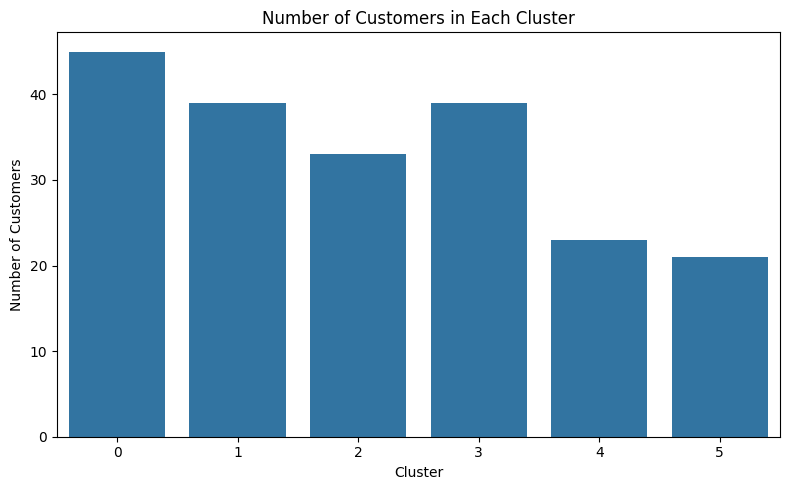

In [39]:
# Visualize cluster sizes

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index.astype(str),
    y=cluster_counts.values
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [40]:
# Calculate the average characteristics of each cluster

cluster_profile = (
    df_clustered
    .groupby("Cluster")[clustering_features]
    .mean()
    .round(2)
)

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,56.33,54.27,49.07
1,26.79,57.10,48.13
2,41.94,88.94,16.97
3,32.69,86.54,82.13
4,25.00,25.26,77.61
5,45.52,26.29,19.38


In [41]:
# Create a detailed profile for each customer cluster

cluster_profile_full = (
    df_clustered
    .groupby("Cluster")
    .agg(
        Customer_Count=("CustomerID", "count"),
        Average_Age=("Age", "mean"),
        Median_Age=("Age", "median"),
        Average_Income=("Annual Income (k$)", "mean"),
        Median_Income=("Annual Income (k$)", "median"),
        Average_Spending=("Spending Score (1-100)", "mean"),
        Median_Spending=("Spending Score (1-100)", "median")
    )
    .round(2)
)

cluster_profile_full

,Customer_Count,Average_Age,Median_Age,Average_Income,Median_Income,Average_Spending,Median_Spending
Cluster,,,,,,,
0,45,56.33,54.0,54.27,54.0,49.07,49.0
1,39,26.79,26.0,57.10,60.0,48.13,50.0
2,33,41.94,43.0,88.94,86.0,16.97,16.0
3,39,32.69,32.0,86.54,79.0,82.13,83.0
4,23,25.00,23.0,25.26,24.0,77.61,77.0
5,21,45.52,46.0,26.29,25.0,19.38,15.0


In [42]:
# Calculate overall averages

overall_profile = (
    df_clustered[clustering_features]
    .mean()
    .round(2)
)

print("Overall dataset averages:")
print(overall_profile)

print("\nCluster averages:")
display(cluster_profile)

Overall dataset averages:
Age                       38.85
Annual Income (k$)        60.56
Spending Score (1-100)    50.20
dtype: float64

Cluster averages:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,56.33,54.27,49.07
1,26.79,57.10,48.13
2,41.94,88.94,16.97
3,32.69,86.54,82.13
4,25.00,25.26,77.61
5,45.52,26.29,19.38


In [43]:
# Compare each cluster with the overall dataset

cluster_vs_overall = cluster_profile.copy()

for feature in clustering_features:
    cluster_vs_overall[feature] = (
        cluster_profile[feature] -
        overall_profile[feature]
    ).round(2)

print("Difference between cluster averages and overall averages:")
cluster_vs_overall

Difference between cluster averages and overall averages:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,17.48,-6.29,-1.13
1,-12.06,-3.46,-2.07
2,3.09,28.38,-33.23
3,-6.16,25.98,31.93
4,-13.85,-35.30,27.41
5,6.67,-34.27,-30.82


In [44]:
# Calculate gender composition within each cluster

gender_cluster_percentage = (
    pd.crosstab(
        df_clustered["Cluster"],
        df_clustered["Gender"],
        normalize="index"
    ) * 100
)

gender_cluster_percentage.round(2)

Gender,Female,Male
Cluster,,
0,57.78,42.22
1,64.10,35.90
2,42.42,57.58
3,53.85,46.15
4,56.52,43.48
5,61.90,38.10


In [45]:
# Count male and female customers in each cluster

gender_cluster_counts = pd.crosstab(
    df_clustered["Cluster"],
    df_clustered["Gender"]
)

gender_cluster_counts

Gender,Female,Male
Cluster,,
0,26,19
1,25,14
2,14,19
3,21,18
4,13,10
5,13,8


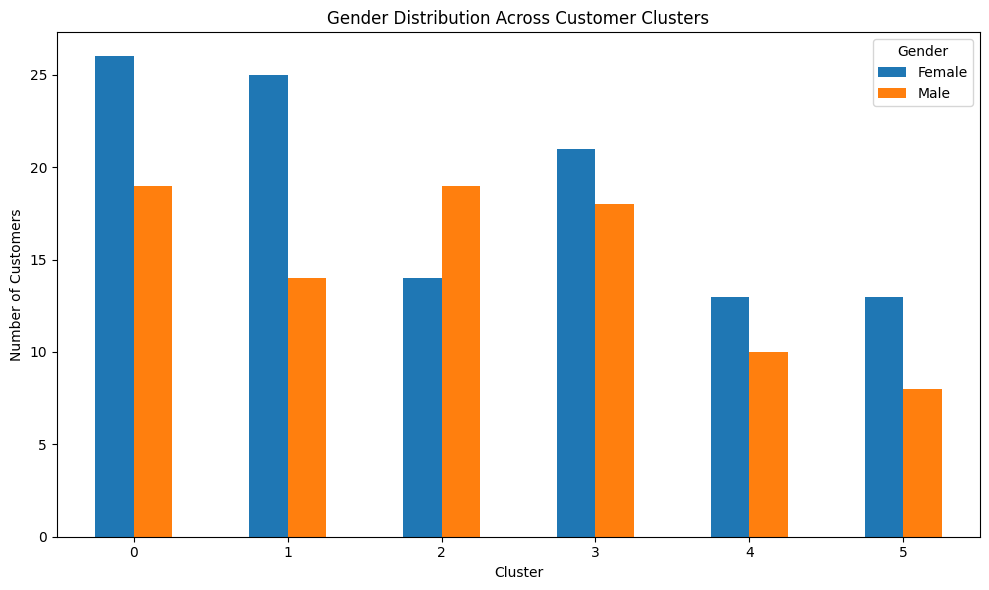

In [46]:
# Visualize gender composition across clusters

gender_cluster_counts.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Gender Distribution Across Customer Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

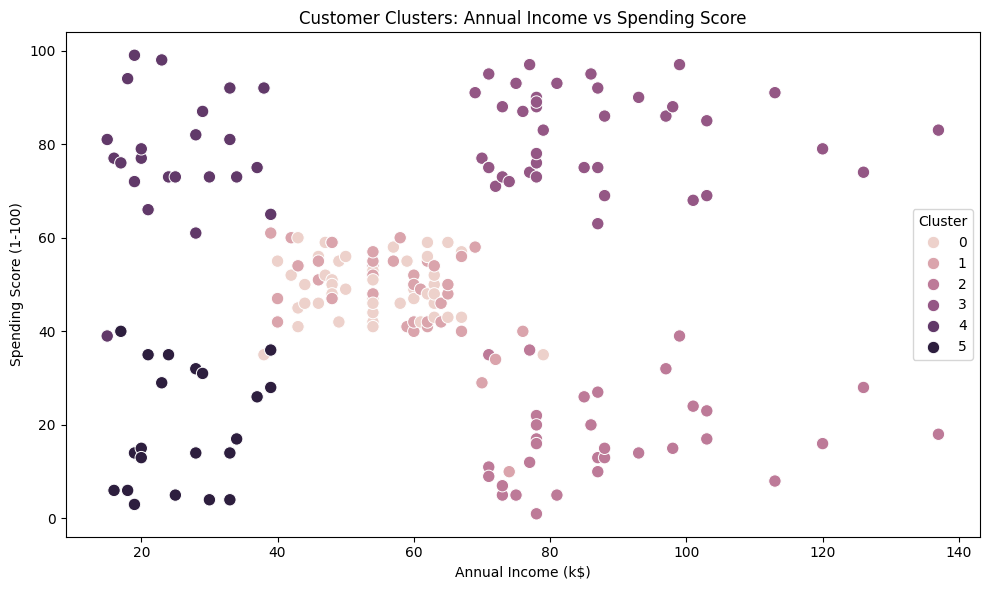

In [47]:
# Visualize customer clusters using income and spending score

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clustered,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    s=80
)

plt.title("Customer Clusters: Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

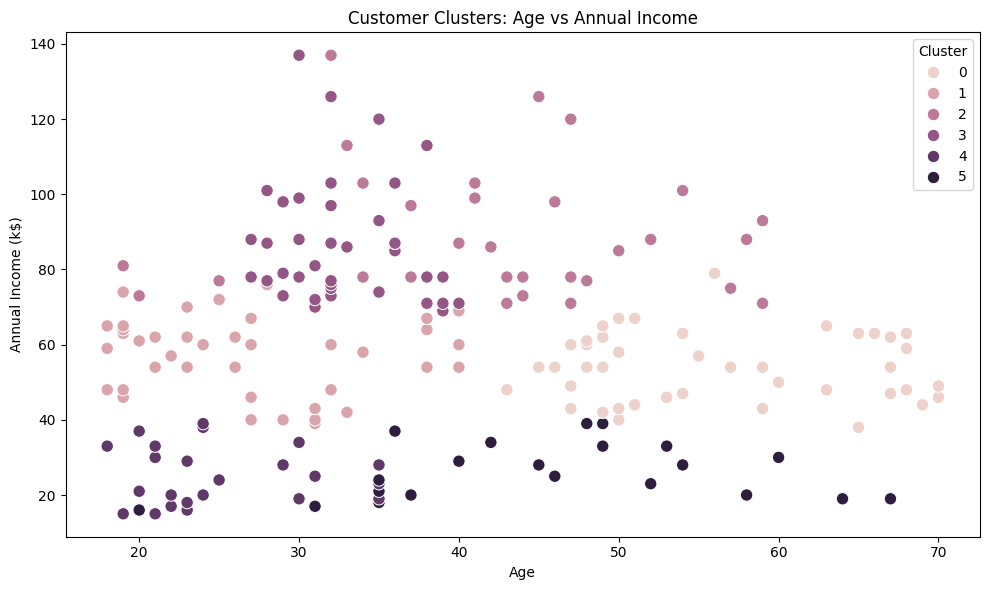

In [48]:
# Visualize clusters using age and annual income

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clustered,
    x="Age",
    y="Annual Income (k$)",
    hue="Cluster",
    s=80
)

plt.title("Customer Clusters: Age vs Annual Income")
plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

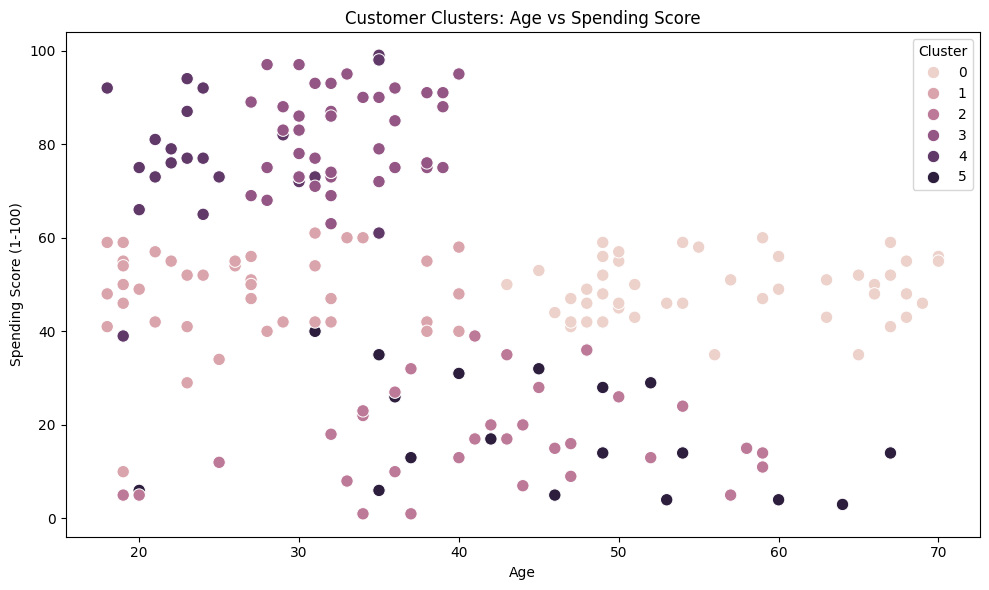

In [49]:
# Visualize clusters using age and spending score

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clustered,
    x="Age",
    y="Spending Score (1-100)",
    hue="Cluster",
    s=80
)

plt.title("Customer Clusters: Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

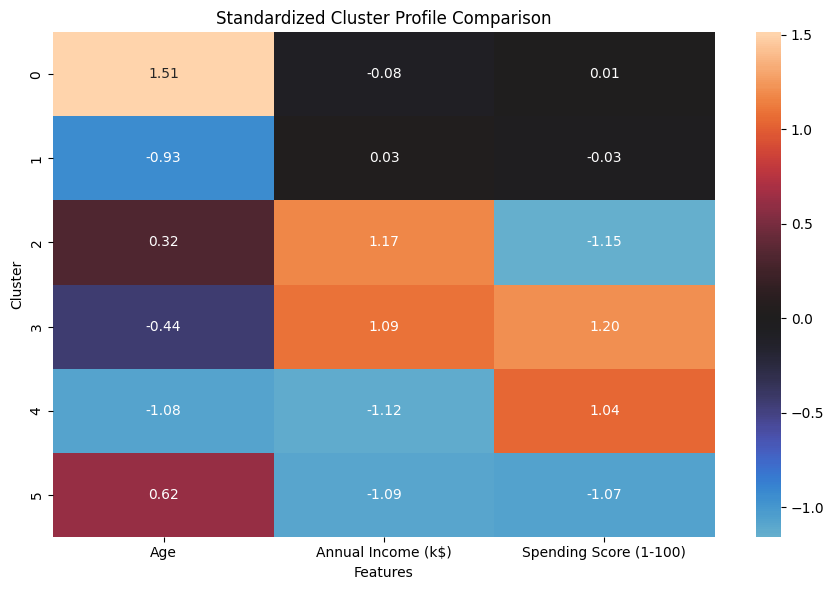

In [50]:
# Standardize cluster averages for comparative visualization

profile_for_heatmap = cluster_profile.copy()

profile_scaled = (
    profile_for_heatmap -
    profile_for_heatmap.mean()
) / profile_for_heatmap.std()

plt.figure(figsize=(9, 6))

sns.heatmap(
    profile_scaled,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Standardized Cluster Profile Comparison")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

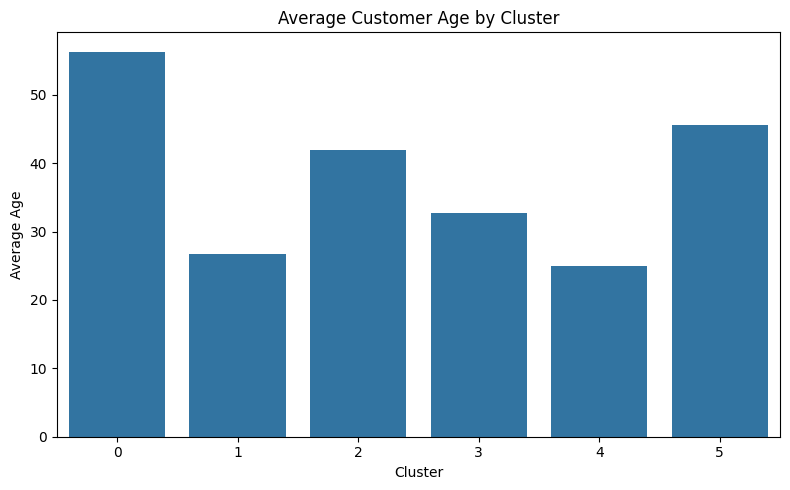

In [51]:
# Compare average age across clusters

age_by_cluster = (
    df_clustered
    .groupby("Cluster")["Age"]
    .mean()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=age_by_cluster.index,
    y=age_by_cluster.values
)

plt.title("Average Customer Age by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Age")
plt.tight_layout()
plt.show()

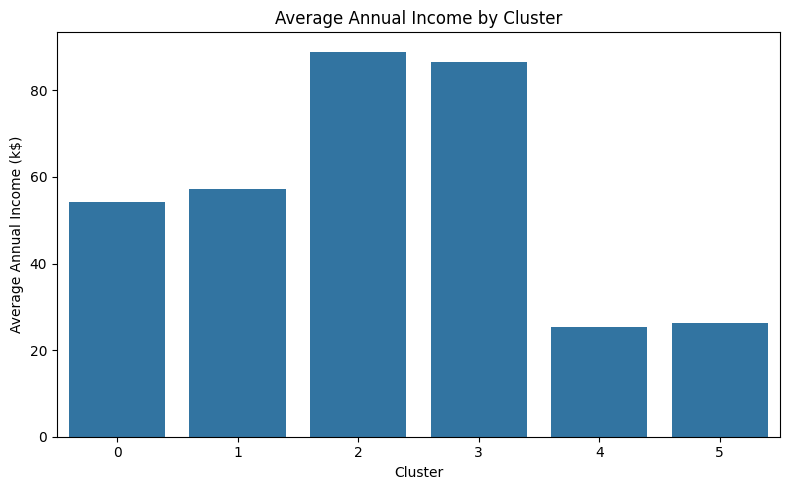

In [52]:
# Compare average annual income across clusters

income_by_cluster = (
    df_clustered
    .groupby("Cluster")["Annual Income (k$)"]
    .mean()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=income_by_cluster.index,
    y=income_by_cluster.values
)

plt.title("Average Annual Income by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Annual Income (k$)")
plt.tight_layout()
plt.show()

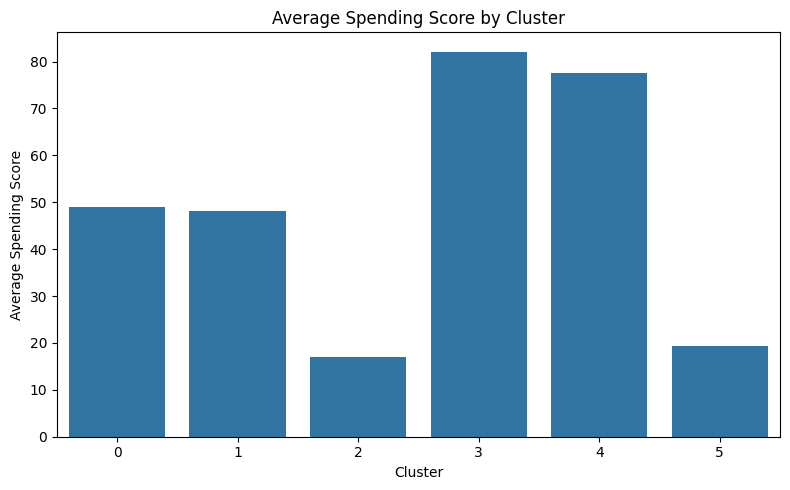

In [53]:
# Compare average spending score across clusters

spending_by_cluster = (
    df_clustered
    .groupby("Cluster")["Spending Score (1-100)"]
    .mean()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=spending_by_cluster.index,
    y=spending_by_cluster.values
)

plt.title("Average Spending Score by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Spending Score")
plt.tight_layout()
plt.show()

In [54]:
# Display detailed information for every cluster

overall_age = df_clustered["Age"].mean()
overall_income = df_clustered["Annual Income (k$)"].mean()
overall_spending = df_clustered["Spending Score (1-100)"].mean()

print("=" * 75)
print("DETAILED CUSTOMER CLUSTER ANALYSIS")
print("=" * 75)

for cluster in sorted(df_clustered["Cluster"].unique()):

    profile = cluster_profile.loc[cluster]

    print(f"\nCLUSTER {cluster}")
    print("-" * 50)

    print(
        f"Number of customers: "
        f"{cluster_counts.loc[cluster]}"
    )

    print(
        f"Cluster percentage: "
        f"{cluster_percentage.loc[cluster]:.2f}%"
    )

    print(
        f"Average age: "
        f"{profile['Age']:.2f}"
    )

    print(
        f"Average annual income: "
        f"{profile['Annual Income (k$)']:.2f} k$"
    )

    print(
        f"Average spending score: "
        f"{profile['Spending Score (1-100)']:.2f}"
    )

    print("\nComparison with overall averages:")

    if profile["Age"] > overall_age:
        print("Age: Above overall average")
    else:
        print("Age: Below overall average")

    if profile["Annual Income (k$)"] > overall_income:
        print("Income: Above overall average")
    else:
        print("Income: Below overall average")

    if profile["Spending Score (1-100)"] > overall_spending:
        print("Spending: Above overall average")
    else:
        print("Spending: Below overall average")

DETAILED CUSTOMER CLUSTER ANALYSIS

CLUSTER 0
--------------------------------------------------
Number of customers: 45
Cluster percentage: 22.50%
Average age: 56.33
Average annual income: 54.27 k$
Average spending score: 49.07

Comparison with overall averages:
Age: Above overall average
Income: Below overall average
Spending: Below overall average

CLUSTER 1
--------------------------------------------------
Number of customers: 39
Cluster percentage: 19.50%
Average age: 26.79
Average annual income: 57.10 k$
Average spending score: 48.13

Comparison with overall averages:
Age: Below overall average
Income: Below overall average
Spending: Below overall average

CLUSTER 2
--------------------------------------------------
Number of customers: 33
Cluster percentage: 16.50%
Average age: 41.94
Average annual income: 88.94 k$
Average spending score: 16.97

Comparison with overall averages:
Age: Above overall average
Income: Above overall average
Spending: Below overall average

CLUSTER 3


In [55]:
# Identify clusters with highest and lowest average values

highest_income_cluster = cluster_profile[
    "Annual Income (k$)"
].idxmax()

lowest_income_cluster = cluster_profile[
    "Annual Income (k$)"
].idxmin()

highest_spending_cluster = cluster_profile[
    "Spending Score (1-100)"
].idxmax()

lowest_spending_cluster = cluster_profile[
    "Spending Score (1-100)"
].idxmin()

youngest_cluster = cluster_profile[
    "Age"
].idxmin()

oldest_cluster = cluster_profile[
    "Age"
].idxmax()

print(
    "Highest average income: "
    f"Cluster {highest_income_cluster}"
)

print(
    "Lowest average income: "
    f"Cluster {lowest_income_cluster}"
)

print(
    "Highest average spending: "
    f"Cluster {highest_spending_cluster}"
)

print(
    "Lowest average spending: "
    f"Cluster {lowest_spending_cluster}"
)

print(
    "Youngest average age: "
    f"Cluster {youngest_cluster}"
)

print(
    "Oldest average age: "
    f"Cluster {oldest_cluster}"
)

Highest average income: Cluster 2
Lowest average income: Cluster 4
Highest average spending: Cluster 3
Lowest average spending: Cluster 2
Youngest average age: Cluster 4
Oldest average age: Cluster 0


In [56]:
# Calculate final silhouette score

final_silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

print("Final clustering evaluation")
print("=" * 50)
print("Number of clusters:", best_k)
print("Final silhouette score:", round(final_silhouette, 4))

Final clustering evaluation
Number of clusters: 6
Final silhouette score: 0.4284


In [57]:
# Save the final clustered dataset

output_file = "Mall_Customers_Clustered.csv"

df_clustered.to_csv(
    output_file,
    index=False
)

print(f"{output_file} saved successfully.")

Mall_Customers_Clustered.csv saved successfully.


In [58]:
# Download the clustered dataset to your computer

files.download("Mall_Customers_Clustered.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
# Perform final validation checks

print("=" * 70)
print("FINAL DATASET VALIDATION")
print("=" * 70)

print("\nOriginal dataset shape:")
print(df.shape)

print("\nFinal clustered dataset shape:")
print(df_clustered.shape)

print("\nMissing values:")
print(df_clustered.isnull().sum())

print("\nTotal missing values:")
print(df_clustered.isnull().sum().sum())

print("\nDuplicate rows:")
print(df_clustered.duplicated().sum())

print("\nCluster distribution:")
print(
    df_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

print("\nColumns:")
print(list(df_clustered.columns))

FINAL DATASET VALIDATION

Original dataset shape:
(200, 5)

Final clustered dataset shape:
(200, 6)

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Cluster                   0
dtype: int64

Total missing values:
0

Duplicate rows:
0

Cluster distribution:
Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64

Columns:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']


In [60]:
# Generate final project summary

print("=" * 75)
print("WEEK 3 - UNSUPERVISED LEARNING AND CLUSTERING")
print("=" * 75)

print(f"\nOriginal records: {len(df)}")

print(
    f"Clustering features: "
    f"{', '.join(clustering_features)}"
)

print(f"Number of clusters selected: {best_k}")

print(
    f"Final silhouette score: "
    f"{final_silhouette:.4f}"
)

print(
    f"Final dataset records: "
    f"{len(df_clustered)}"
)

print(
    f"Total missing values: "
    f"{df_clustered.isnull().sum().sum()}"
)

print(
    f"Duplicate rows: "
    f"{df_clustered.duplicated().sum()}"
)

print("\nCluster distribution:")

for cluster in sorted(cluster_counts.index):

    count = cluster_counts.loc[cluster]
    percentage = cluster_percentage.loc[cluster]

    print(
        f"Cluster {cluster}: "
        f"{count} customers "
        f"({percentage:.2f}%)"
    )

print("\nFinal cluster profile:")
display(cluster_profile_full)

print("\nProject analysis completed successfully.")

WEEK 3 - UNSUPERVISED LEARNING AND CLUSTERING

Original records: 200
Clustering features: Age, Annual Income (k$), Spending Score (1-100)
Number of clusters selected: 6
Final silhouette score: 0.4284
Final dataset records: 200
Total missing values: 0
Duplicate rows: 0

Cluster distribution:
Cluster 0: 45 customers (22.50%)
Cluster 1: 39 customers (19.50%)
Cluster 2: 33 customers (16.50%)
Cluster 3: 39 customers (19.50%)
Cluster 4: 23 customers (11.50%)
Cluster 5: 21 customers (10.50%)

Final cluster profile:


,Customer_Count,Average_Age,Median_Age,Average_Income,Median_Income,Average_Spending,Median_Spending
Cluster,,,,,,,
0,45,56.33,54.0,54.27,54.0,49.07,49.0
1,39,26.79,26.0,57.10,60.0,48.13,50.0
2,33,41.94,43.0,88.94,86.0,16.97,16.0
3,39,32.69,32.0,86.54,79.0,82.13,83.0
4,23,25.00,23.0,25.26,24.0,77.61,77.0
5,21,45.52,46.0,26.29,25.0,19.38,15.0



Project analysis completed successfully.
